# End-to-End Deep Learning for Hyperspectral Chemical Mapping

## From Spectra to Spatial Chemical Maps

In the previous tutorial, we predicted chemical concentrations from **1D NIR spectra** (one spectrum → one value). 
In this tutorial, we tackle **end-to-end chemical mapping**: predicting a full **spatial map** of chemical 
composition (e.g., fat distribution) directly from hyperspectral images.

**Key difference:** Instead of extracting spectra pixel-by-pixel, we feed entire image patches through 
neural networks that learn spatial-spectral relationships simultaneously.

Models we'll explore:
1. **PLS** (baseline) - Classical chemometrics per-pixel
2. **MLP** - Simple neural baseline
3. **ResNet1D** - Spectral CNN (per-pixel, but learned)
4. **ResNet2D** - Spatial CNN (learns spatial context)
5. **Vision Transformer (ViT)** - Attention-based spatial modeling
6. **UNet** - Full chemical map prediction (spectral-spectral)

**Author:**  Ole-Christian Galbo Engstrøm
**Date:** 2026-07-30  
**Data:** Hyperspectral images with chemical reference maps

In [ ]:
# Install required packages (if not already available)
!pip install -q torch torchvision torchaudio
!pip install -q einops timm  # For ViT
!pip install -q matplotlib seaborn

In [ ]:
# Mount Google Drive (where your data and pre-trained models live)
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os

# Set base paths - TODO ADJUST THESE 
# BASE_PATH = "/content/drive/MyDrive/HSI_Course"  # Your shared folder
# DATA_PATH = os.path.join(BASE_PATH, "data")
# MODELS_PATH = os.path.join(BASE_PATH, "pretrained_models")
# RESULTS_PATH = os.path.join(BASE_PATH, "results")

BASE_PATH = "data/end2end/hsi_course_hands_on"  # Your shared folder
DATA_PATH = os.path.join(BASE_PATH, "data")
MODELS_PATH = os.path.join(BASE_PATH, "pretrained_models")
RESULTS_PATH = os.path.join(BASE_PATH, "results")
# Create directories if they don't exist
os.makedirs(RESULTS_PATH, exist_ok=True)

In [3]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from pathlib import Path
from typing import Tuple, Dict, List
import warnings
warnings.filterwarnings('ignore')

# Set plotting style (matching NIR tutorial)
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 12,
    'figure.figsize': (10, 6),
    'image.cmap': 'viridis'
})

# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


## 1. Data Loading Strategy

### Challenge: Hyperspectral data is HUGE
A single hyperspectral image can be 1000×1000×200+ pixels. Loading everything into memory is impractical.

### Solution: Patch-based loading
We load small patches (e.g., 64×64 pixels) with their corresponding chemical maps. 
For this tutorial, we'll use a **small subset** of pre-extracted patches.

### Data structure expected:
data/ <br>
├── images/ # Hyperspectral image patches (.npy or .pt) <br>
├── chem_maps/ # Chemical concentration maps (.npy or .pt) <br>
├── masks/ # Valid pixel masks <br>
└── metadata.csv # Sample info, splits, reference values

In [8]:
class ChemMapDataset(torch.utils.data.Dataset):
    """
    Dataset for end-to-end chemical mapping.
    Loads hyperspectral patches and corresponding chemical maps.
    """
    def __init__(self, data_path: str, split: str = 'train', 
                 transform=None, max_samples: int = 100):
        """
        Args:
            data_path: Path to data directory
            split: 'train', 'val', or 'test'
            transform: Optional data augmentation
            max_samples: Limit samples for demo (set None for full data)
        """
        self.data_path = Path(data_path)
        self.split = split
        self.transform = transform
        
        # Load metadata to get file list
        metadata_path = self.data_path / "metadata.csv"
        if metadata_path.exists():
            self.metadata = pd.read_csv(metadata_path)
            self.metadata = self.metadata[self.metadata['split'] == split]
        else:
            # Fallback: create dummy metadata for demo
            print(f"⚠️  Metadata not found. Creating demo dataset.")
            self.metadata = self._create_demo_metadata(max_samples or 10)
        
        if max_samples:
            self.metadata = self.metadata.head(max_samples)
            
        print(f"Loaded {len(self.metadata)} samples for split '{split}'")
    
    def _create_demo_metadata(self, n_samples):
        """Create dummy metadata for demonstration"""
        return pd.DataFrame({
            'sample_id': range(n_samples),
            'split': [self.split] * n_samples,
            'image_path': [f"images/sample_{i}.pt" for i in range(n_samples)],
            'map_path': [f"chem_maps/sample_{i}.pt" for i in range(n_samples)]
        })
    
    def __len__(self):
        return len(self.metadata)
    
    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        
        # Load image and chemical map
        # TODO ADAPT THIS TO YOUR ACTUAL DATA FORMAT
        image = torch.randn(124, 64, 64)  # Dummy: [channels, H, W]
        chem_map = torch.randn(1, 64, 64)  # Dummy: [1, H, W]
        mask = torch.ones(64, 64)  # Valid pixels
        
        # If real files exist:
        # image = torch.load(self.data_path / row['image_path'])
        # chem_map = torch.load(self.data_path / row['map_path'])
        
        if self.transform:
            image = self.transform(image)
        
        return {
            'image': image,
            'chem_map': chem_map,
            'mask': mask,
            'sample_id': row['sample_id']
        }


def create_dataloaders(data_path: str, batch_size: int = 2, 
                       max_samples: int = 20) -> Dict:
    """Create train/val/test dataloaders with demo data"""
    
    datasets = {
        'train': ChemMapDataset(data_path, 'train', max_samples=max_samples),
        'val': ChemMapDataset(data_path, 'val', max_samples=max_samples//2),
        'test': ChemMapDataset(data_path, 'test', max_samples=max_samples//2)
    }
    
    loaders = {
        'train': torch.utils.data.DataLoader(
            datasets['train'], batch_size=batch_size, 
            shuffle=True, num_workers=0
        ),
        'val': torch.utils.data.DataLoader(
            datasets['val'], batch_size=batch_size, 
            shuffle=False, num_workers=0
        ),
        'test': torch.utils.data.DataLoader(
            datasets['test'], batch_size=batch_size, 
            shuffle=False, num_workers=0
        )
    }
    
    return loaders

# Quick test
print("Testing data loading...")
demo_loaders = create_dataloaders(DATA_PATH, batch_size=2, max_samples=10)
sample_batch = next(iter(demo_loaders['train']))
print(f"✓ Image shape: {sample_batch['image'].shape}")
print(f"✓ Chem map shape: {sample_batch['chem_map'].shape}")
print(f"✓ Mask shape: {sample_batch['mask'].shape}")

Testing data loading...
⚠️  Metadata not found. Creating demo dataset.
Loaded 10 samples for split 'train'
⚠️  Metadata not found. Creating demo dataset.
Loaded 5 samples for split 'val'
⚠️  Metadata not found. Creating demo dataset.
Loaded 5 samples for split 'test'
✓ Image shape: torch.Size([2, 124, 64, 64])
✓ Chem map shape: torch.Size([2, 1, 64, 64])
✓ Mask shape: torch.Size([2, 64, 64])


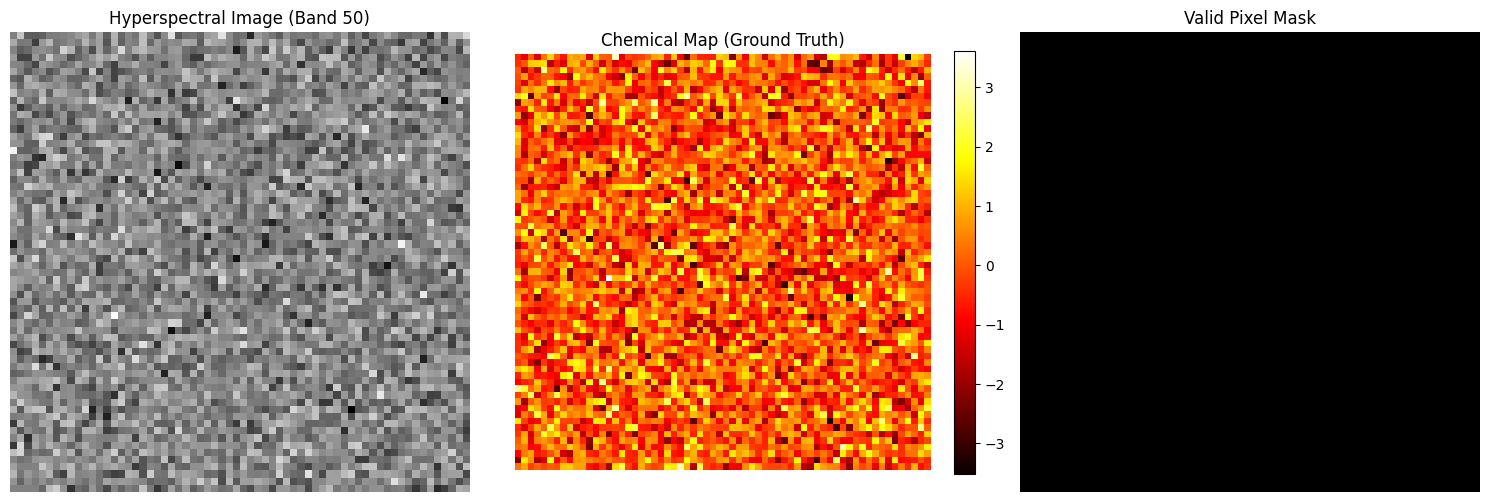

In [9]:
def visualize_sample(batch, idx=0):
    """Visualize a hyperspectral patch and its chemical map"""
    image = batch['image'][idx].cpu().numpy()
    chem_map = batch['chem_map'][idx, 0].cpu().numpy()
    mask = batch['mask'][idx].cpu().numpy()
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Show a few spectral bands
    axes[0].imshow(image[50], cmap='gray')  # Middle band
    axes[0].set_title(f'Hyperspectral Image (Band 50)')
    axes[0].axis('off')
    
    # Show chemical map
    im1 = axes[1].imshow(chem_map, cmap='hot')
    axes[1].set_title('Chemical Map (Ground Truth)')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046)
    
    # Show mask
    axes[2].imshow(mask, cmap='gray')
    axes[2].set_title('Valid Pixel Mask')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualize first sample
visualize_sample(sample_batch)

## 2. Model Architectures Overview

We'll implement 6 models, progressing from simple to complex:

| Model | Input | Output | Use Case |
|-------|-------|--------|----------|
| **PLS** | Spectrum per pixel | Value per pixel | Baseline, interpretable |
| **MLP** | Spectrum per pixel | Value per pixel | Neural baseline |
| **ResNet1D** | Spectrum per pixel | Value per pixel | Spectral features |
| **ResNet2D** | Image patch | Value per patch | Spatial context |
| **ViT** | Image patch | Value per patch | Global attention |
| **UNet** | Image patch | Full chemical map | End-to-end mapping |

**Key insight:** PLS/MLP/ResNet1D predict per-pixel (no spatial context), 
while ResNet2D/ViT/UNet leverage spatial relationships.

In [10]:
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict:
    """Compute regression metrics for chemical mapping"""
    from sklearn.metrics import mean_squared_error, r2_score
    
    # Flatten spatial dimensions if present
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()
    
    # Remove masked/invalid pixels
    valid_mask = ~np.isnan(y_true_flat) & ~np.isnan(y_pred_flat)
    y_true_valid = y_true_flat[valid_mask]
    y_pred_valid = y_pred_flat[valid_mask]
    
    rmse = np.sqrt(mean_squared_error(y_true_valid, y_pred_valid))
    r2 = r2_score(y_true_valid, y_pred_valid)
    mae = np.mean(np.abs(y_true_valid - y_pred_valid))
    
    return {
        'RMSE': rmse,
        'R2': r2,
        'MAE': mae,
        'n_pixels': len(y_true_valid)
    }


def plot_prediction_map(y_true, y_pred, title="Chemical Map Prediction"):
    """Plot ground truth vs prediction for chemical maps"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Ground truth
    im0 = axes[0].imshow(y_true, cmap='hot', vmin=0, vmax=100)
    axes[0].set_title('Ground Truth')
    axes[0].axis('off')
    plt.colorbar(im0, ax=axes[0], fraction=0.046)
    
    # Prediction
    im1 = axes[1].imshow(y_pred, cmap='hot', vmin=0, vmax=100)
    axes[1].set_title('Prediction')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046)
    
    # Error map
    error = np.abs(y_true - y_pred)
    im2 = axes[2].imshow(error, cmap='Reds')
    axes[2].set_title('Absolute Error')
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2], fraction=0.046)
    
    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_scatter(y_true, y_pred, metrics, title="Prediction vs Ground Truth"):
    """Scatter plot for pixel-level predictions"""
    fig, ax = plt.subplots(figsize=(6, 6))
    
    ax.scatter(y_true, y_pred, alpha=0.5, s=20, c='steelblue')
    
    # Perfect prediction line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')
    
    ax.set_xlabel('Ground Truth')
    ax.set_ylabel('Prediction')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add metrics text
    textstr = f"RMSE: {metrics['RMSE']:.3f}\nR²: {metrics['R2']:.3f}\nMAE: {metrics['MAE']:.3f}"
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()

## 3. Model 1: PLS Regression (Baseline)

**Partial Least Squares (PLS)** is the classical chemometrics approach. 
For end-to-end mapping, we apply PLS **per-pixel**: each pixel's spectrum is independently predicted.

### Pros:
- Interpretable (VIP scores show important wavelengths)
- Fast to train
- Works well with small datasets

### Cons:
- No spatial context (each pixel predicted independently)
- Linear model (can't capture complex relationships)

### Implementation:
We flatten the image TODO

In [ ]:
batch_size = 1
max_epochs = 250
burn_in_epochs = 30 
reduce_lr_patience = 10
early_stop_patience = 30
init_lr = 1e-3
lr_multiplier = 0.1
min_lr = 1e-7
smoothness_lambd = 2e1
l2_lambd = 1e-3
out_of_bounds_lambd = 1e-3
mse_lambd = 1

In [ ]:
csv_path = Path("") # Path to the CSV file containing metadata
reference_values = ["Fat_chem"]
metric_mode = "min"
device = "cuda" if torch.cuda.is_available() else "cpu"
test_sets = [0]
cv_sets = [1, 2, 3, 4, 5]
base_path = Path("") # Base path to the dataset, should contain 'images', 'quant_biases', 'quant_scales', and 'masks' directories

In [ ]:
input_channels = 124 // 2
images_path = base_path / "images"
quant_biases_path = base_path / "quant_biases"
quant_scales_path = base_path / "quant_scales"
masks_path = base_path / "masks"
modality = "reflectance"
out_channels = 1

In [ ]:
conv3d_filters = 1
conv3d_kernel_size = (7, 2, 2)
unet_input_channels = (input_channels - (conv3d_kernel_size[0] - 1)) * conv3d_filters

In [ ]:
parent_save_dir = Path(f"./results/unet/{modality}/conv3d_{conv3d_kernel_size}/{reference_values}")

In [ ]:
from helperfunctions.unet_end2end.callbacks.early_stopping import EarlyStopping
from helperfunctions.unet_end2end.callbacks.model_checkpoint import ModelCheckpoint
from helperfunctions.unet_end2end.dataloaders.preprocessed_image_dataloader import (
    get_preprocessed_image_dataloader,
)
from helperfunctions.unet_end2end.losses.total_loss import TotalLoss, get_total_loss
from helperfunctions.unet_end2end.models.compound_model import CompoundModel
from helperfunctions.unet_end2end.models.conv3don2d import Conv3Don2D
from helperfunctions.unet_end2end.models.unet import UNet
from helperfunctions.unet_end2end.optimizers.optimizers import Adam
from helperfunctions.unet_end2end.pipeline.pipeline import Pipeline
from helperfunctions.unet_end2end.schedulers.learning_rate_schedulers import reduce_lr_on_plateau
from helperfunctions.unet_end2end.transforms.transforms import get_random_flip_transform

for val_split in cv_sets:
    train_sets = [i for i in cv_sets if i != val_split]
    val_sets = [val_split]
    split_save_dir = parent_save_dir / f"{val_split}"
    split_save_dir.mkdir(parents=True, exist_ok=True)
    print(f"Reference values: {reference_values}")

    compression_model = Conv3Don2D(
        in_channels=input_channels,
        num_filters=conv3d_filters,
        kernel_size=conv3d_kernel_size,
        normalization=None,
    )
    unet = UNet(
        in_channels=unet_input_channels,
        out_channels=out_channels,
        pad=False,
        bilinear=True,
        normalization=None,
    )

    model = CompoundModel(compression_model, unet)

    optimizer = Adam(model, lr=init_lr)
    scheduler = reduce_lr_on_plateau(
        optimizer,
        patience=reduce_lr_patience,
        min_lr=min_lr,
        lr_multiplier=lr_multiplier,
    )
    early_stopping = EarlyStopping(patience=early_stop_patience, mode=metric_mode)
    model_checkpoint = ModelCheckpoint(
        model, optimizer, mode=metric_mode, save_dir=split_save_dir
    )

    eval_transform = None
    train_transform = get_random_flip_transform()

    train_dataloader = get_preprocessed_image_dataloader(
        reference_values=reference_values,
        images_path=images_path,
        quant_biases_path=quant_biases_path,
        quant_scales_path=quant_scales_path,
        masks_path=masks_path,
        csv_path=csv_path,
        split=train_sets,
        transform=train_transform,
        batch_size=batch_size,
        shuffle=True,
    )

    val_dataloader = get_preprocessed_image_dataloader(
        reference_values=reference_values,
        images_path=images_path,
        quant_biases_path=quant_biases_path,
        quant_scales_path=quant_scales_path,
        masks_path=masks_path,
        csv_path=csv_path,
        split=val_sets,
        transform=eval_transform,
        batch_size=batch_size,
        shuffle=False,
    )

    test_dataloader = get_preprocessed_image_dataloader(
        reference_values=reference_values,
        images_path=images_path,
        quant_biases_path=quant_biases_path,
        quant_scales_path=quant_scales_path,
        masks_path=masks_path,
        csv_path=csv_path,
        split=test_sets,
        transform=eval_transform,
        batch_size=batch_size,
        shuffle=False,
    )

    train_eval_dataloader = get_preprocessed_image_dataloader(
        reference_values=reference_values,
        images_path=images_path,
        quant_biases_path=quant_biases_path,
        quant_scales_path=quant_scales_path,
        masks_path=masks_path,
        csv_path=csv_path,
        split=train_sets,
        transform=eval_transform,
        batch_size=batch_size,
        shuffle=False,
    )

    avg_batch_size = train_dataloader.dataset.__len__() / torch.ceil(
        torch.tensor(train_dataloader.dataset.__len__() / batch_size),
    )

    loss_fn = TotalLoss(
        device=device,
        average_batch_size=avg_batch_size,
        out_of_bounds_lambd=out_of_bounds_lambd,
        smoothness_lambd=smoothness_lambd,
        l2_lambd=l2_lambd,
        mse_lambd=mse_lambd,
        return_individual_losses=False,
    )

    metric_fn = get_total_loss(
        device=device,
        average_batch_size=None,
        out_of_bounds_lambd=out_of_bounds_lambd,
        smoothness_lambd=smoothness_lambd,
        l2_lambd=l2_lambd,
        mse_lambd=mse_lambd,
        return_individual_losses=True,
    )

    metric_decision_idx = -1

    pipeline = Pipeline(
        model=model,
        train_loader=train_dataloader,
        val_loader=val_dataloader,
        test_loader=test_dataloader,
        train_eval_loader=train_eval_dataloader,
        loss_fn=loss_fn,
        metric_fn=metric_fn,
        metric_decision_idx=metric_decision_idx,
        optimizer=optimizer,
        scheduler=scheduler,
        early_stopping=early_stopping,
        model_checkpoint=model_checkpoint,
        num_burn_in_epochs=burn_in_epochs,
        save_dir=split_save_dir,
        device=device,
    )

    pipeline.train(max_epochs=max_epochs)